In [1]:
%load_ext autoreload
%autoreload 2


%run ./src/run.py --help


usage: run.py [-h] [--seed SEED] --experiment
              {mnist2,pmnist,cifar,mixture,easy-chasy,hard-chasy,smnist}
              --approach
              {random,sgd,sgd-frozen,lwf,lfl,ewc,imm-mean,progressive,pathnet,imm-mode,sgd-restart,ewc2,ewc-film,joint,hat,hat-test,gvcl,vcl,vclf,gvclf}
              [--reg_type {kl_g,re_g,kl_qg,t_st}] [--q Q] [--v V]
              [--output OUTPUT] [--nepochs NEPOCHS] [--lr LR]
              [--parameter PARAMETER] [--ntasks NTASKS] [--momentum MOMENTUM]
              [--weight_decay WEIGHT_DECAY] [--beta BETA] [--lamb LAMB]
              [--root_path ROOT_PATH]
              [--use-best-hyperparams USE_BEST_HYPERPARAMS]
              [--use-sweep USE_SWEEP] [--train_samples TRAIN_SAMPLES]

xxx

options:
  -h, --help            show this help message and exit
  --seed SEED           (default=0)
  --experiment {mnist2,pmnist,cifar,mixture,easy-chasy,hard-chasy,smnist}
                        (default=)
  --approach {random,sgd,sgd-frozen,lwf,l

## Test functions for the regularizer

In [11]:
import torch
import torch.distributions as dist

def compute_kl(mean, exp_var, prior_mean, prior_exp_var, sum = True, lamb = 1, initial_prior_var = 1):
    #print("mean shape:", mean.shape)
    #print("exp_var shape:", exp_var.shape)
    #print("prior_mean shape:", prior_mean.shape)
    #print("prior_exp_var shape:", prior_exp_var.shape)
    trace_term = torch.exp(exp_var - prior_exp_var)
    if lamb != 1:
        mean_term =  (mean - prior_mean)**2 * (lamb * torch.clamp(torch.exp(-prior_exp_var) - (1/initial_prior_var), min = 0.0) + (1/initial_prior_var))
    else:
        mean_term =  (mean - prior_mean)**2 * torch.exp(-prior_exp_var)
    det_term = prior_exp_var - exp_var
    
    if sum:
        return 0.5 * torch.sum(trace_term + mean_term + det_term - 1)
    else:
        return 0.5 * (trace_term + mean_term + det_term - 1)

def compute_renyi(mean, log_var, prior_mean, log_prior_var,  sum = True, lamb = 1, initial_prior_var = 1, alpha = 0.5):
    """
    Compute the Rényi divergence between univariate Gaussian posterior and prior distributions.
    
    Args:
        mean (torch.Tensor): Posterior mean (shape: [n]).
        log_var (torch.Tensor): Log-variance of the posterior (shape: [n]).
        prior_mean (torch.Tensor): Prior mean (shape: [n]).
        log_prior_var (torch.Tensor): Log-variance of the prior (shape: [n]).
        alpha (float): Order of the Rényi divergence (alpha > 0, alpha != 1).
    
    Returns:
        torch.Tensor: Rényi divergence for each element in the input tensor (shape: [n]).
    """
    # Compute posterior variance and prior variance from log-variances
    var = torch.exp(log_var)  # Posterior variance
    prior_var = torch.exp(log_prior_var)  # Prior variance

    # Compute the mixed variance (Σ_α)^*
    mixed_var = alpha * prior_var + (1 - alpha) * var

    # Compute the Mahalanobis term: α (μ - μ_prior)^2 / (Σ_α)^*
    mahalanobis_term = alpha * (mean - prior_mean) ** 2 / mixed_var

    # Compute the determinant term: log(|Σ_α^*|) - ((1 - α) log(|Σ|) + α log(|Σ_prior|))
    log_det_term = torch.log(mixed_var) - ((1 - alpha) * log_var + alpha * log_prior_var)

    if sum:
        return 0.5 * torch.sum(mahalanobis_term - 0.5 / (alpha - 1) * log_det_term)
    # Combine terms to compute Rényi divergence
    else:
        return 0.5 * mahalanobis_term - 0.5 / (alpha - 1)

def compute_kl_true(mean, exp_var, prior_mean, prior_exp_var, sum = True, lamb = 1, initial_prior_var = 1):

    '''
    Computes the Dkl(approximate distribution || prior distribution) between two Gaussian distributions

    Note that the variances are log variances
    '''

    dist1 = dist.MultivariateNormal(mean, exp_var)
    dist2 = dist.MultivariateNormal(prior_mean, prior_exp_var)
    kl_loss = torch.distributions.kl.kl_divergence(dist1, dist2)
    return kl_loss

In [24]:
import torch
from math import gamma as gamma_function
import math

def compute_psi_vectorized(v, log_sigma):
    """
    Compute Ψ for the d-dimensional case using degrees of freedom v.
    Works with log-space sigma.
    
    Parameters:
    -----------
    v : float
        Degrees of freedom (v > 0)
    log_sigma : torch.Tensor
        Log variance parameter of shape (d,)
        
    Returns:
    --------
    torch.Tensor
        The computed Ψ values of shape (d,)
    """
    k = log_sigma.shape[0]
    # Ensure k does not equal v
    if k == v:
        raise ValueError("k cannot equal v")
    # Compute numerator: Γ((v+1)/2)
    numerator = gamma_function((v + k) / 2)
    
    # Compute denominator parts
    pi_v_term = (math.pi * v)**(k/2)
    gamma_term = gamma_function(v/2)
    
    # Convert to tensor for broadcasting
    numerator = torch.tensor(numerator, dtype=torch.float32)
    pi_v_term = torch.tensor(pi_v_term, dtype=torch.float32)
    gamma_term = torch.tensor(gamma_term, dtype=torch.float32)
    
    # Use log_sigma directly and exp(log_sigma/2) for sqrt(sigma)
    sigma_term = torch.prod(torch.exp(log_sigma/2))
    
    # Combine terms
    base = numerator / (pi_v_term * gamma_term * sigma_term)
    
    # Raise to power -2/(v+1)
    psi = base ** (-2/(v + k))
    
    return psi

def multivariate_t_divergence(mu1, mu2, log_sigma1, log_sigma2, v, sum = True):
    """
    Calculate the element-wise t-divergence between two d-dimensional distributions.
    
    Parameters:
    -----------
    mu1 : torch.Tensor
        Mean of the first distribution, shape (d,)
    mu2 : torch.Tensor
        Mean of the second distribution, shape (d,)
    log_sigma1 : torch.Tensor
        Log variance of the first distribution, shape (d,)
    log_sigma2 : torch.Tensor
        Log variance of the second distribution, shape (d,)
    v : int or torch.Tensor
        Degrees of freedom (v > 0). Keep between values of 1.0 and 50.0 (the larger it gets, t converges to 1 as in the Gaussian)
        
    Returns:
    --------
    torch.Tensor
        The element-wise t-divergence values, shape (d,)
    """
    
    # Check if v is positive
    if v <= 0:
        raise ValueError("Degrees of freedom v must be positive")
    
    # Ensure all inputs have the same shape
    assert mu1.shape == mu2.shape == log_sigma1.shape == log_sigma2.shape, "All inputs must have the same shape"
    
    # Calculate t from v: t = 2/(v+1) + 1
    t = 2/(v + 1) + 1
    
    # Compute Ψ₁ and Ψ₂ (now returns tensors of shape (d,))
    psi1 = compute_psi_vectorized(v, log_sigma1)
    psi2 = compute_psi_vectorized(v, log_sigma2)
    
    # Common denominator terms
    den = 1 - t  # = -2/(v+1)
    
    # Convert log_sigma2 to sigma2 for calculations
    sigma1 = torch.exp(log_sigma1)
    sigma2 = torch.exp(log_sigma2)
    v_sigma2 = v * sigma2
    
    # Calculate each term (element-wise operations)
    term1 = (psi1/den) * (1 + 1/v)
    term2 = (2 * psi2/den) * (mu1 * mu2/v_sigma2)
    term3 = -(psi2/den) * (sigma1/v_sigma2)
    term4 = -(psi2/den) * (mu1 * mu1/v_sigma2)
    term5 = -(psi2/den) * (mu2 * mu2/v_sigma2 + 1)
    
    # Combine all terms
    if sum:
        #divergence = torch.pow(torch.sum(torch.pow((term1 + term2 + term3 + term4 + term5),den)) - (dim - 1), 1/den)
        divergence = torch.sum(term1 + term2 + term3 + term4 + term5)
    else:
        divergence = term1 + term2 + term3 + term4 + term5
    
    return divergence

def example_usage():
    # Example parameters with d-dimensional arrays
    d = 3  # number of dimensions
    mu1 = torch.tensor([1.0, 0.5, 2.0])
    mu2 = torch.tensor([2.0, 1.5, 0.0])
    log_sigma1 = torch.tensor([0.0, 0.5, 0.5])  # log space
    log_sigma2 = torch.tensor([0.4, 0.0, 0.3])  # log space
    v = 60.0  # degrees of freedom (v > 0)
    
    try:
        result = multivariate_t_divergence(mu1, mu2, log_sigma1, log_sigma2, v)
        print(f"T-divergence for v={v}:")
        print(f"Dimension-wise results: {result}")
        print(f"Mean divergence: {result.mean().item()}")
        
        # Also print the implied t value
        t = 2/(v + 1) + 1
        print(f"Implied t value: {t}")
        
        return result
    except Exception as e:
        print(f"Error computing t-divergence: {e}")
        return None

if __name__ == "__main__":
    example_usage()

T-divergence for v=60.0:
Dimension-wise results: 2.411762237548828
Mean divergence: 2.411762237548828
Implied t value: 1.0327868852459017


In [25]:
# Example parameters with d-dimensional arrays
d = 10  # number of dimensions
mu1 = torch.tensor([1.0, 0.5, 2.0, 1.5, 0.0, -1.0, 0.3, 0.7, -0.5, 1.2])
mu2 = torch.tensor([2.0, 1.5, 0.0, -0.5, 1.0, 0.5, -0.3, -0.7, 0.5, -1.2])
log_sigma1 = torch.tensor([0.0, 0.5, 0.5, 0.2, 0.3, 0.1, 0.4, 0.6, 0.2, 0.3])  # log space
log_sigma2 = torch.tensor([0.4, 0.0, 0.3, 0.1, 0.2, 0.5, 0.6, 0.2, 0.3, 0.1])  # log space
v = 20.0  # degrees of freedom (v > 0)
    

result = multivariate_t_divergence(mu1, mu2, log_sigma1, log_sigma2, v)

Sanity check that what is being done is computing the KL for a diagonal covariance matrix. With compute_kl true we can introduce interdependencies, try with it as well

In [15]:
# Example usage
# Example usage for 10x10 diagonal covariance matrix
mu1 = torch.tensor([0.0] * 10)
cov1 = torch.diag(torch.tensor([1.0] * 10))
mu2 = torch.tensor([1.0] * 10)
cov2 = torch.diag(torch.tensor([2.0] * 10))

mu1_univariate = torch.tensor([0.0])
cov1_univariate = torch.tensor([[1.0]])
mu2_univariate = torch.tensor([1.0])
cov2_univariate = torch.tensor([[2.0]])

kl_loss = compute_kl_true(mu1, cov1, mu2, cov2)
kl_term = compute_kl(mu1, torch.log(torch.diag(cov1)), mu2, torch.log(torch.diag(cov2)))
renyi_term = compute_renyi(mu1, torch.log(torch.diag(cov1)), mu2, torch.log(torch.diag(cov2)))

kl_loss_univariate = compute_kl_true(mu1_univariate, cov1_univariate, mu2_univariate, cov2_univariate)
kl_term_univariate2 = compute_kl(mu1_univariate, torch.log(cov1_univariate), mu2_univariate, torch.log(cov2_univariate))
renyi_term_univariate = compute_renyi(mu1_univariate, torch.log(cov1_univariate), mu2_univariate, torch.log(cov2_univariate))

print("KL Loss multivariate (torch implementation):", kl_loss)
print("KL loss:", kl_term)
print("Renyi term multivariate:", renyi_term)

print("KL Loss univariate (torch implementation):", kl_loss_univariate)
print("KL loss:", kl_term_univariate2)
print("Renyi term univariate:", renyi_term_univariate)



KL Loss multivariate (torch implementation): tensor(3.4657)
KL loss: tensor(3.4657)
Renyi term multivariate: tensor(1.9611)
KL Loss univariate (torch implementation): tensor(0.3466)
KL loss: tensor(0.3466)
Renyi term univariate: tensor(0.1961)


## Renyi entropy of the escort distribution

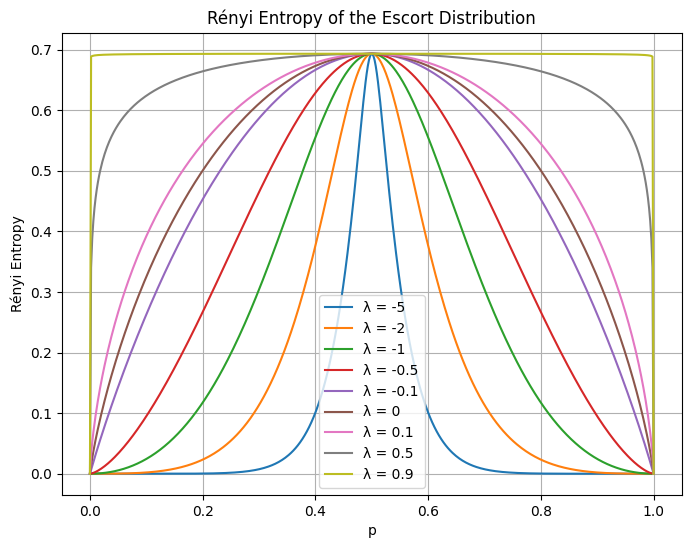

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def escort_distribution(p, alpha):
    """
    Compute the escort distribution for a given p and alpha.

    Parameters:
    - p: array-like, probabilities of the original distribution
    - alpha: float, deformation parameter (same as q)

    Returns:
    - Escort distribution: normalized deformed probabilities
    """
    deformed_p = p ** alpha
    return deformed_p / np.sum(deformed_p)

def renyi_entropy(p, alpha):
    """
    Compute the Rényi entropy for the escort distribution.

    Parameters:
    - p: array-like, probabilities of the original distribution
    - alpha: float, deformation parameter (same as q)

    Returns:
    - Rényi entropy value
    """
    if alpha == 1:
        # Shannon entropy as a special case
        return -np.sum(p * np.log(p + 1e-12))
    else:
        return (1 / (1 - alpha)) * np.log(np.sum(p ** alpha))

def plot_renyi_entropy():
    """
    Plot the Rényi entropy of the escort distribution as a function of p
    for different values of alpha (or lambda).
    """
    p_values = np.linspace(0, 1, 500)  # p values in [0, 1]
    lambdas = [-5, -2, -1, -0.5, -0.1, 0, 0.1, 0.5, 0.9]  # Lambda values
    alpha_values = [1 - lam for lam in lambdas]  # Alpha = 1 - lambda
    entropy_values = []

    for alpha in alpha_values:
        entropies = []
        for p in p_values:
            original_p = np.array([p, 1 - p])  # Binary distribution
            escort_p = escort_distribution(original_p, alpha)
            entropy = renyi_entropy(escort_p, alpha)
            entropies.append(entropy)
        entropy_values.append(entropies)

    # Plot the results
    plt.figure(figsize=(8, 6))
    for i, lam in enumerate(lambdas):
        plt.plot(p_values, entropy_values[i], label=f"λ = {lam}")
    plt.xlabel("p")
    plt.ylabel("Rényi Entropy")
    plt.title("Rényi Entropy of the Escort Distribution")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the updated plot function
plot_renyi_entropy()


## Play with efficient ways to sample from a student-t distribution


In [3]:
def sample_student_t(shape, df, device="cuda", dtype=torch.float32):
    """
    Efficiently sample from a Student's t-distribution using PyTorch.
    
    Parameters:
        shape (tuple): The shape of the output samples.
        df (float): Degrees of freedom of the Student's t-distribution.
        loc (float): Mean (location parameter) of the distribution.
        scale (float): Scale parameter of the distribution.
        device (str): The device to use ('cpu' or 'cuda').
        dtype (torch.dtype): The data type for the samples.

    Returns:
        torch.Tensor: Samples from the Student's t-distribution.
    """
    # Generate standard normal samples
    X = torch.empty(shape, device=device).normal_(mean=0,std=1)
    
    # Generate chi-squared samples
    Z = torch.distributions.Chi2(df).sample(shape).to(device=device)
    
    # Transform to Student's t-distribution
    Y = X * torch.rsqrt(Z / df)
    
    # Apply location and scale
    return Y

In [4]:
import torch
import time
import numpy as np
from typing import Tuple, Optional

def sample_student_t_bailey(shape: Tuple[int, ...], df: float, device: str = "cuda",
                          dtype: torch.dtype = torch.float32) -> torch.Tensor:
    """
    Implements Bailey's algorithm for Student's t sampling, which is more efficient
    for large-scale sampling as it avoids explicitly generating chi-squared samples.
    Based on: Bailey, R.W. (1994) "Polar Generation of Random Variates with the t-Distribution"
    
    Parameters:
        shape (tuple): The shape of the output samples
        df (float): Degrees of freedom
        device (str): Device to use ('cpu' or 'cuda')
        dtype (torch.dtype): Data type for the samples
        
    Returns:
        torch.Tensor: Samples from the Student's t-distribution
    """
    half_df = df / 2
    batch_shape = shape if isinstance(shape, tuple) else (shape,)
    
    # Pre-allocate tensors
    u = torch.empty(batch_shape, device=device, dtype=dtype)
    v = torch.empty(batch_shape, device=device, dtype=dtype)
    
    # Generate uniform samples
    u.uniform_(-1, 1)
    v.uniform_(0, 1)
    
    # Calculate radius
    r_squared = u * u + v * v
    
    # Initialize mask for rejection sampling
    mask = r_squared >= 1
    
    # Rejection sampling loop
    while mask.any():
        # Resample only where mask is True
        u_new = torch.empty_like(u[mask]).uniform_(-1, 1)
        v_new = torch.empty_like(v[mask]).uniform_(0, 1)
        r_squared_new = u_new * u_new + v_new * v_new
        
        # Update values where r_squared >= 1
        u[mask] = u_new
        v[mask] = v_new
        r_squared[mask] = r_squared_new
        mask = r_squared >= 1
    
    # Transform to Student's t
    factor = torch.pow(v * (df / r_squared), 1 / df)
    return u * factor

def sample_student_t_box_muller(shape: Tuple[int, ...], df: float, device: str = "cuda",
                               dtype: torch.dtype = torch.float32) -> torch.Tensor:
    """
    Uses Box-Muller transform combined with gamma sampling for Student's t distribution.
    More efficient than naive chi-squared approach for large batches.
    
    Parameters:
        shape (tuple): The shape of the output samples
        df (float): Degrees of freedom
        device (str): Device to use ('cpu' or 'cuda')
        dtype (torch.dtype): Data type for the samples
        
    Returns:
        torch.Tensor: Samples from the Student's t-distribution
    """
    # Generate standard normal using Box-Muller
    u1 = torch.empty(shape, device=device, dtype=dtype).uniform_(0, 1)
    u2 = torch.empty(shape, device=device, dtype=dtype).uniform_(0, 1)
    
    r = torch.sqrt(-2 * torch.log(u1))
    theta = 2 * np.pi * u2
    X = r * torch.cos(theta)
    
    # Generate gamma samples for denominator
    gamma = torch.distributions.Gamma(df/2, 1/2).sample(shape).to(device=device)
    
    # Combine to get Student's t
    return X * torch.rsqrt(gamma * 2 / df)

def benchmark_samplers(shape: Tuple[int, ...], df: float, n_runs: int = 10) -> dict:
    """
    Benchmark different sampling methods for Student's t distribution.
    
    Parameters:
        shape (tuple): Shape of samples to generate
        df (float): Degrees of freedom
        n_runs (int): Number of runs for timing
        
    Returns:
        dict: Dictionary containing timing results and memory usage
    """
    methods = {
        'Original': sample_student_t,
        'Bailey': sample_student_t_bailey,
        'Box-Muller': sample_student_t_box_muller
    }
    
    results = {}
    
    for name, method in methods.items():
        # Warm-up run
        _ = method(shape, df)
        torch.cuda.synchronize()
        
        # Time multiple runs
        start = time.perf_counter()
        for _ in range(n_runs):
            _ = method(shape, df)
            torch.cuda.synchronize()
        end = time.perf_counter()
        
        # Measure memory
        torch.cuda.reset_peak_memory_stats()
        _ = method(shape, df)
        torch.cuda.synchronize()
        max_memory = torch.cuda.max_memory_allocated() / 1024**2  # Convert to MB
        
        results[name] = {
            'avg_time': (end - start) / n_runs,
            'max_memory_mb': max_memory
        }
    
    return results

# Example usage and benchmarking
if __name__ == "__main__":
    # Test shapes representing different network sizes
    test_shapes = [
        (1000, 1000),  # 1M parameters
        (10000, 1000), # 10M parameters
        (50000, 1000)  # 50M parameters
    ]
    df = 5.0
    
    print("Benchmarking Student's t sampling methods:")
    print("=" * 50)
    
    for shape in test_shapes:
        print(f"\nShape: {shape} (Total elements: {np.prod(shape):,})")
        results = benchmark_samplers(shape, df)
        
        for method, stats in results.items():
            print(f"\n{method}:")
            print(f"  Average time: {stats['avg_time']*1000:.2f} ms")
            print(f"  Peak memory: {stats['max_memory_mb']:.1f} MB")

Benchmarking Student's t sampling methods:

Shape: (1000, 1000) (Total elements: 1,000,000)

Original:
  Average time: 55.36 ms
  Peak memory: 20.0 MB

Bailey:
  Average time: 2.89 ms
  Peak memory: 24.8 MB

Box-Muller:
  Average time: 55.23 ms
  Peak memory: 35.3 MB

Shape: (10000, 1000) (Total elements: 10,000,000)

Original:
  Average time: 551.94 ms
  Peak memory: 190.7 MB

Bailey:
  Average time: 15.30 ms
  Peak memory: 239.3 MB

Box-Muller:
  Average time: 553.75 ms
  Peak memory: 343.3 MB

Shape: (50000, 1000) (Total elements: 50,000,000)

Original:
  Average time: 2741.42 ms
  Peak memory: 953.7 MB

Bailey:
  Average time: 66.35 ms
  Peak memory: 1192.1 MB

Box-Muller:
  Average time: 2739.16 ms
  Peak memory: 1716.6 MB


In [6]:
import torch
import time
import numpy as np
from typing import Tuple, Optional
from scipy import stats
import matplotlib.pyplot as plt
from torch.distributions import StudentT

# [Previous sampling functions remain the same...]

def test_sampling_methods(n_samples: int = 100000, df: float = 5.0, 
                         device: str = "cuda", plot: bool = True) -> dict:
    """
    Test different sampling methods for statistical correctness and consistency.
    
    Parameters:
        n_samples: Number of samples to generate for testing
        df: Degrees of freedom for the t-distribution
        device: Device to use for computations
        plot: Whether to create visualization plots
    
    Returns:
        Dictionary containing test results
    """
    # Define sampling methods
    methods = {
        'Original': sample_student_t,
        'Bailey': sample_student_t_bailey,
        'Box-Muller': sample_student_t_box_muller,
        'PyTorch': lambda shape, df, device: StudentT(df=df).sample(shape).to(device)
    }
    
    # Generate samples from each method
    samples = {}
    theoretical_stats = {}
    for name, method in methods.items():
        samples[name] = method((n_samples,), df, device).cpu().numpy()
    
    # Statistical tests results
    results = {name: {} for name in methods.keys()}
    
    # Reference theoretical moments
    theoretical_mean = 0
    theoretical_var = df / (df - 2) if df > 2 else float('inf')
    
    # Compute and compare statistics
    for name, sample in samples.items():
        # Basic statistics
        results[name]['mean'] = np.mean(sample)
        results[name]['std'] = np.std(sample)
        results[name]['skewness'] = stats.skew(sample)
        results[name]['kurtosis'] = stats.kurtosis(sample)
        
        # Kolmogorov-Smirnov test against theoretical distribution
        ks_stat, ks_pval = stats.kstest(sample, 't', args=(df,))
        results[name]['ks_stat'] = ks_stat
        results[name]['ks_pval'] = ks_pval
    
    # Print results
    print("\nStatistical Test Results:")
    print("=" * 50)
    for name, stats_results in results.items():
        print(f"\n{name} Method:")
        print(f"Mean: {stats_results['mean']:.4f} (should be close to {theoretical_mean})")
        print(f"Std: {stats_results['std']:.4f} (should be close to {np.sqrt(theoretical_var) if df > 2 else 'inf'})")
        print(f"Skewness: {stats_results['skewness']:.4f} (should be close to 0)")
        print(f"Kurtosis: {stats_results['kurtosis']:.4f}")
        print(f"KS test p-value: {stats_results['ks_pval']:.4f} (should be > 0.05)")
    
    # Plotting
    if plot:
        fig = plt.figure(figsize=(15, 10))
        
        # Histogram subplot
        plt.subplot(2, 1, 1)
        for name, sample in samples.items():
            plt.hist(sample, bins=100, density=True, alpha=0.3, label=name)
        
        # Add theoretical PDF
        x = np.linspace(-4, 4, 1000)
        plt.plot(x, stats.t.pdf(x, df), 'k-', lw=2, label='Theoretical PDF')
        
        plt.title(f'Student t Distribution (df={df})')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.legend()
        plt.grid(True)
        
        # Q-Q plots subplot
        plt.subplot(2, 1, 2)
        for name, sample in samples.items():
            # Create Q-Q plot for each method
            theoretical_quantiles = stats.t.ppf(np.linspace(0.01, 0.99, 100), df)
            sample_quantiles = np.quantile(sample, np.linspace(0.01, 0.99, 100))
            plt.plot(theoretical_quantiles, sample_quantiles, 'o', label=name, alpha=0.5)
            
        # Add reference line
        plt.plot([-4, 4], [-4, 4], 'k--', alpha=0.8, label='Reference Line')
        plt.xlabel('Theoretical Quantiles')
        plt.ylabel('Sample Quantiles')
        plt.title('Q-Q Plot')
        plt.legend()
        plt.grid(True)
        
        plt.tight_layout()
        plt.savefig('student_t_comparison.png')
        plt.close()
    
    return results

if __name__ == "__main__":
    # Test with different degrees of freedom
    dfs = [3.0, 5.0, 10.0]
    
    for df in dfs:
        print(f"\nTesting with df = {df}")
        results = test_sampling_methods(n_samples=100000, df=df)
        
        # Test for consistency between methods
        samples = {
            'Original': sample_student_t((10000,), df).cpu(),
            'Bailey': sample_student_t_bailey((10000,), df).cpu(),
            'Box-Muller': sample_student_t_box_muller((10000,), df).cpu()
        }
        
        # Compare distributions between methods using KS test
        print("\nConsistency Tests Between Methods:")
        print("=" * 50)
        for name1 in samples:
            for name2 in samples:
                if name1 < name2:  # Avoid duplicate comparisons
                    ks_stat, p_val = stats.ks_2samp(
                        samples[name1].numpy(),
                        samples[name2].numpy()
                    )
                    print(f"{name1} vs {name2}:")
                    print(f"KS test p-value: {p_val:.4f} (should be > 0.05)")


Testing with df = 3.0

Statistical Test Results:

Original Method:
Mean: -0.0042 (should be close to 0)
Std: 1.6742 (should be close to 1.7320508075688772)
Skewness: -0.0531 (should be close to 0)
Kurtosis: 26.3998
KS test p-value: 0.9360 (should be > 0.05)

Bailey Method:
Mean: -0.0015 (should be close to 0)
Std: 0.5777 (should be close to 1.7320508075688772)
Skewness: 0.0025 (should be close to 0)
Kurtosis: -1.3730
KS test p-value: 0.0000 (should be > 0.05)

Box-Muller Method:
Mean: -0.0015 (should be close to 0)
Std: 1.2240 (should be close to 1.7320508075688772)
Skewness: 0.6342 (should be close to 0)
Kurtosis: 112.0353
KS test p-value: 0.0000 (should be > 0.05)

PyTorch Method:
Mean: 0.0050 (should be close to 0)
Std: 1.6981 (should be close to 1.7320508075688772)
Skewness: -1.0917 (should be close to 0)
Kurtosis: 71.4850
KS test p-value: 0.1572 (should be > 0.05)

Consistency Tests Between Methods:
Bailey vs Original:
KS test p-value: 0.0000 (should be > 0.05)
Bailey vs Box-Mull


Testing with df = 3.0


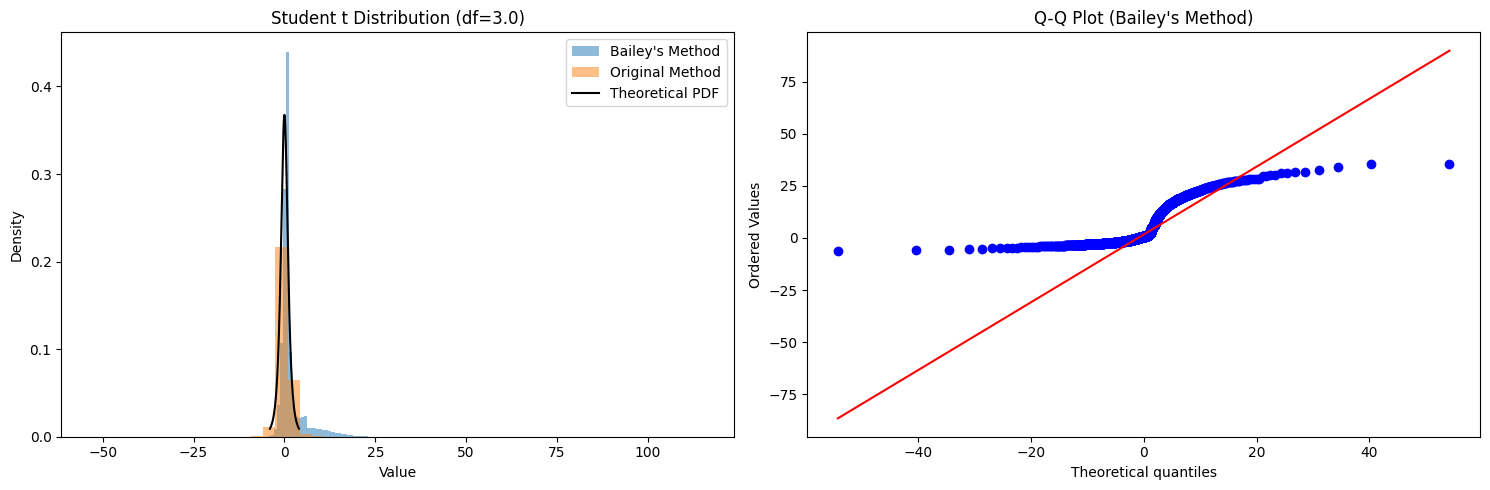


Bailey's Method Statistics:
Mean: 1.6170 (should be close to 0)
Std: 3.3793 (should be close to 1.7320508075688772)
Skewness: 2.9548 (should be close to 0)
KS test p-value: 0.0000 (should be > 0.05)

KS test between Bailey and Original: p-value = 0.0000

Testing with df = 5.0


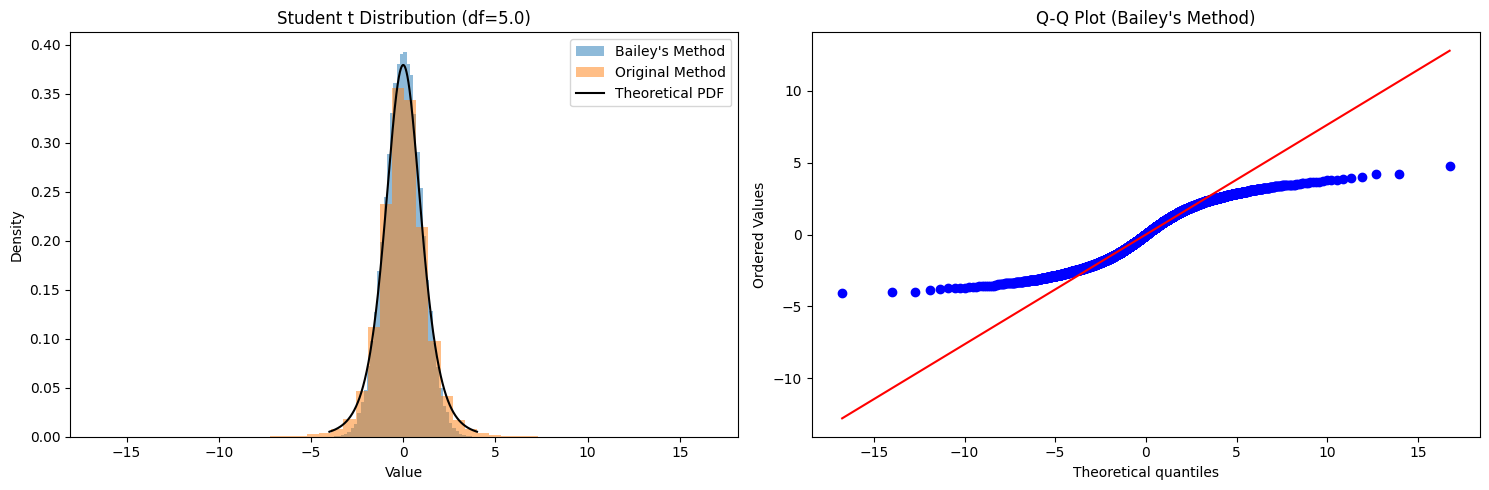


Bailey's Method Statistics:
Mean: 0.0023 (should be close to 0)
Std: 1.0008 (should be close to 1.2909944487358056)
Skewness: -0.0039 (should be close to 0)
KS test p-value: 0.0000 (should be > 0.05)

KS test between Bailey and Original: p-value = 0.0000

Testing with df = 10.0


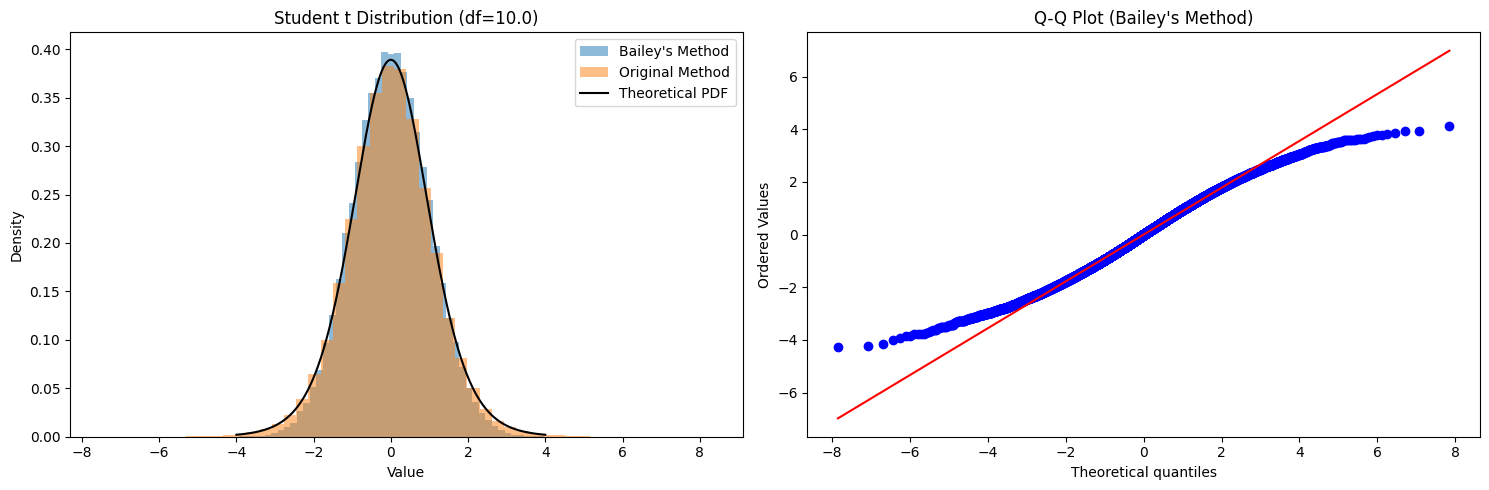


Bailey's Method Statistics:
Mean: 0.0019 (should be close to 0)
Std: 0.9961 (should be close to 1.118033988749895)
Skewness: 0.0191 (should be close to 0)
KS test p-value: 0.0000 (should be > 0.05)

KS test between Bailey and Original: p-value = 0.0000


In [7]:
import torch
import time
import numpy as np
from typing import Tuple, Optional
from scipy import stats
import matplotlib.pyplot as plt

def sample_student_t_bailey(shape: Tuple[int, ...], df: float, device: str = "cuda",
                          dtype: torch.float32 = torch.float32) -> torch.Tensor:
    """
    Implementation of Bailey's algorithm for Student's t sampling.
    The key is in properly handling the transformation and scaling factors.
    
    Reference: Bailey, R.W. (1994) "Polar Generation of Random Variates 
    with the t-Distribution"
    """
    batch_shape = shape if isinstance(shape, tuple) else (shape,)
    
    # Initialize results tensor
    result = torch.empty(batch_shape, device=device, dtype=dtype)
    
    # Generate samples iteratively to ensure correctness
    remaining = torch.ones(batch_shape, device=device, dtype=torch.bool)
    
    while remaining.any():
        # Generate uniform random variables for points that still need sampling
        u1 = torch.empty_like(result[remaining]).uniform_(-1, 1)
        u2 = torch.empty_like(result[remaining]).uniform_(-1, 1)
        
        # Calculate squared radius
        w = u1 * u1 + u2 * u2
        
        # Only keep points inside the unit circle
        mask = w < 1
        
        if mask.any():
            # Apply the transformation for accepted points
            u1_accepted = u1[mask]
            w_accepted = w[mask]
            
            # Transform to Student's t using correct formula
            t = u1_accepted * torch.sqrt(df * (torch.pow(w_accepted, -2/df) - 1) / w_accepted)
            
            # Update only the remaining points that were successfully generated
            result[remaining][mask] = t
            remaining[remaining.nonzero()[mask]] = False
    
    return result

def verify_distribution(df: float = 5.0, n_samples: int = 100000, device: str = "cuda"):
    """
    Verify the corrected Bailey implementation against original and theoretical distribution.
    """
    # Generate samples from different methods
    bailey_samples = sample_student_t_bailey((n_samples,), df, device).cpu().numpy()
    original_samples = sample_student_t((n_samples,), df, device).cpu().numpy()
    
    # Create comparison plots
    plt.figure(figsize=(15, 5))
    
    # Histogram
    plt.subplot(121)
    plt.hist(bailey_samples, bins=50, density=True, alpha=0.5, label="Bailey's Method")
    plt.hist(original_samples, bins=50, density=True, alpha=0.5, label="Original Method")
    
    # Add theoretical PDF
    x = np.linspace(-4, 4, 1000)
    plt.plot(x, stats.t.pdf(x, df), 'k-', label='Theoretical PDF')
    
    plt.title(f'Student t Distribution (df={df})')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    
    # Q-Q plot
    plt.subplot(122)
    stats.probplot(bailey_samples, dist="t", sparams=(df,), plot=plt)
    plt.title("Q-Q Plot (Bailey's Method)")
    
    plt.tight_layout()
    plt.show()
    
    # Statistical tests
    print("\nBailey's Method Statistics:")
    print(f"Mean: {np.mean(bailey_samples):.4f} (should be close to 0)")
    print(f"Std: {np.std(bailey_samples):.4f} (should be close to {np.sqrt(df/(df-2)) if df > 2 else 'inf'})")
    print(f"Skewness: {stats.skew(bailey_samples):.4f} (should be close to 0)")
    
    # KS test
    ks_stat, p_val = stats.kstest(bailey_samples, 't', args=(df,))
    print(f"KS test p-value: {p_val:.4f} (should be > 0.05)")
    
    # Compare with original method
    ks_stat, p_val = stats.ks_2samp(bailey_samples, original_samples)
    print(f"\nKS test between Bailey and Original: p-value = {p_val:.4f}")

if __name__ == "__main__":
    # Test the corrected implementation
    dfs = [3.0, 5.0, 10.0]
    
    for df in dfs:
        print(f"\nTesting with df = {df}")
        verify_distribution(df=df)